## 1. Import Library

In [ ]:
import pandas as pd
pd.options.mode.chained_assignment = None
import numpy as np
seed = 0
np.random.seed(seed)
import matplotlib.pyplot as plt
import seaborn as sns

import datetime as dt
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

!pip install pySastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

from wordcloud import WordCloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 6.6 MB/s eta 0:00:00


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 2. Load Dataset

In [ ]:
df = pd.read_csv('ulasan_gojek_kategori.csv')

In [ ]:
jumlah_ulasan, jumlah_kolom = df.shape

print(jumlah_ulasan)
print(jumlah_kolom)

12000
2


In [ ]:
df.head()

,Review,Kategori
0,"kak,knapa coin saya tidak bisa bertambah/tidk ...",Kualitas Teknis & Aplikasi
1,driver suka tidak mengabari bisa jemput atau t...,Interaksi & Pelayanan Driver
2,Tolong perjelas perbedaan antara GoFood biasa ...,Respons Pengembang & CS
3,kok gojek dan gopay aneh sekali dihp saya. pad...,Kualitas Teknis & Aplikasi
4,"sebelumnya mohon maaf atas rating nya, kendala...",Kualitas Teknis & Aplikasi


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review    12000 non-null  object
 1   Kategori  12000 non-null  object
dtypes: object(2)
memory usage: 187.6+ KB


In [ ]:
print(f"Jumlah duplikasi data ulasan: {df.duplicated().sum()}")

Jumlah duplikasi data ulasan: 10


In [ ]:
df_clean = df.dropna()

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Review    12000 non-null  object
 1   Kategori  12000 non-null  object
dtypes: object(2)
memory usage: 187.6+ KB


In [ ]:
df_clean = df_clean.drop_duplicates()
jumlah_ulasan_setelah_hapus_duplikat, jumlah_kolom_setelah_hapus_duplikat = df_clean.shape

In [ ]:
slangwords = {"@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget","gak": "tidak","gk": "tidak",
"indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know",
"ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan",
"ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi",
"aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang",
"ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi",
"bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan",
"beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh",
"blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga",
"bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong",
"buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren",
"calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat",
"cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong",
"cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall",
"cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik",
"dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat",
"dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana",
"drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya",
"emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi",
"gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja",
"gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol",
"githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa",
"gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he",
"helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah",
"humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja",
"jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar",
"jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan",
"kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya",
"kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau",
"kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau",
"klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya",
"komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim",
"kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara",
"latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan",
"lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu",
"lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo","vermuk": "verifikasi muka",
"mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali",
"mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa",
"mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional",
"muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana",
"napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri",
"ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan",
"ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis",
"ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara",
"ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing",
"ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu",
"ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan",
"pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri","bobrok":"tidak layak",
"pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah",
"perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin", "nunggu" : "menunggu", "kena" : "terkena", "knapa" : "kenapa", "bbrp" : "beberapa", "mklum" : "maklum", "becus" : "cakap", "sring" : "sering", "kcwa" : "kecewa", "aplkasi" : "aplikasi", "udh" : "sudah", "ga" : "tidak", "apk" : "aplikasi", "cuma" : "hanya", "pesen" : "pesan", "gabisa" : "tidak bisa", "tetep" : "tetap", "trus" : "terus", "gini" : "begini", "app" : "aplikasi", "sdh" : "sudah", "jek" : "gejek", "tiba2" : "tiba-tiba", "no" : "nomor", "dr" : "dari", "skrg" : "sekarang", "kayak" : "sepertinya", "batalin" : "batalkan", "emang" : "memang", "kasian" : "kasihan", "cuman" : "hanya", "pdhl" : "padahal", "sya" : "saya", "tuh" : "itu", "soalnya" : "karena", "doang" : "saja", "dipake" : "dipakai", "dikasih" : "diberi", "deket" : "dekat", "dicancel" : "dibatalkan", "males" : "malas", "mesen" : "memesan", "dg" : "dengan", "eror" : "error", "notif" : "notifikasi", "nomer" : "nomor", "dibatalin" : "dibatalkan", "yaa" : "ya", "uninstal" : "uninstall", "muter" : "berputar", "sm" : "sama", "dikit" : "sedikit", "yah" : "ya", "org" : "orang", "kesel" : "kesal", "gajelas" : "tidak jelas", "skrg" : "sekarang", "uda" : "sudah", "gampang" : "mudah", "duit" : "uang", "udahh" : "sudah", "drivernya" : "driver nya", "gitu" : "begitu", "bgtlah" : "banget", "parahhh" : "parah", "lemottt": "lambat", "ngelag": "lag", "ngeload": "memuat" , "ngebug": "bug", "kepotong": "terpotong", "kepake": "terpakai", "kepencet": "terpencet", "ketahan": "tertahan", "ketrigger": "terpicu", "kedaftar": "terdaftar", "gopud": "gofood", "gocar": "go car", "goride": "go ride", "gojekin": "memesan gojek", "drivercancel": "driver batal", "dicancel": "dibatalkan", "cancel": "batal", "cancelin": "batalkan", "ngecancel": "membatalkan", "orderan": "pesanan", "ngechat": "mengirim pesan", "nelfon": "menelepon", "kehide": "tersembunyi", "keblok": "terblokir", "kebanned": "terblokir", "ngefreeze": "macet", "crash": "gagal", "forceclose": "aplikasi tertutup sendiri", "loadingnya": "proses muatnya", "ngeloadnya": "proses memuatnya", "keupdate": "terperbarui", "diupdate": "diperbarui", "maintenis": "maintenance", "notif": "notifikasi", "otp": "kode verifikasi", "verif": "verifikasi", "cs": "customer service", "cust": "pelanggan", "app": "aplikasi", "apk": "aplikasi", "rekomen": "rekomendasi", "overall": "secara keseluruhan", "worthit": "layak", "ribet": "rumit", "ngeribetin": "mempersulit", "mager": "malas bergerak", "zonk": "buruk", "mantul": "mantap betul", "okee": "oke", "okeee": "oke", "sippp": "bagus", "helpfull": "membantu", "recommended": "direkomendasikan", "besttt": "terbaik", "slowrespon": "lambat merespon", "responnya": "tanggapannya", "kecewash": "kecewa", "ngeluh": "mengeluh", "ngerjain": "mengerjakan", "dipersulit": "dibuat sulit", "ngerampas": "merampas", "ngelock": "mengunci", "uninstall": "hapus aplikasi", "install": "pasang aplikasi", "reinstall": "pasang ulang aplikasi", "HP": "handphone", "bolak-balok": "Bolak Balok", "ujan" : "hujan", "krn" : "karena", "nentuin" : "menentukan", "bs" : "bisa", "ga" : "tidak", "sy" : "saya", "lg" : "lagi"}

def fix_slangwords(text):
    words = text.split()
    fix_words = []

    for word in words:
        if word.lower() in slangwords:
            fix_words.append(slangwords[word.lower()])
        else:
            fix_words.append(word)

    fix_text = ' '.join(fix_words)
    return fix_text

In [ ]:
print(jumlah_ulasan_setelah_hapus_duplikat)
print(jumlah_kolom_setelah_hapus_duplikat)

11990
2


## 3. Preprocessing Text

In [ ]:
def cleaningText(text):
  text = re.sub(r'@[A-Za-z0-9]+', '', text)
  text = re.sub(r'#[A-Za-z0-9]+', '', text)
  text = re.sub(r'RT[\s]', '', text)
  text = re.sub(r"http\S+", '', text)
  text = re.sub(r'[0-9]+', '', text)
  text = re.sub(r'[^\w\s]', '', text)

  text = text.replace('\n', ' ')
  text = text.translate(str.maketrans('', '', string.punctuation))
  text = text.strip(' ')
  return text

def casefoldingText(text):
  text = text.lower()
  return text

def tokenizingText(text):
  text = word_tokenize(text)
  return text

def filteringText(text):
  listStopwords = set(stopwords.words('indonesian'))
  listStopwords1 = set(stopwords.words('english'))
  listStopwords.update(listStopwords1)
  listStopwords.update(['iya','yaa','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy","wkwk","wkwkwk"])
  filtered = []
  for txt in text:
    if txt not in listStopwords:
      filtered.append(txt)
  text = filtered
  return text

def stemmingText(words):
  factory = StemmerFactory()
  stemmer = factory.create_stemmer()

  stemmed_words = [stemmer.stem(word) for word in words]

  return stemmed_words

def toSentence(list_words):
  sentence = ' '.join(word for word in list_words)
  return sentence

In [ ]:
df_clean

,Review,Kategori
0,"kak,knapa coin saya tidak bisa bertambah/tidk ...",Kualitas Teknis & Aplikasi
1,driver suka tidak mengabari bisa jemput atau t...,Interaksi & Pelayanan Driver
2,Tolong perjelas perbedaan antara GoFood biasa ...,Respons Pengembang & CS
3,kok gojek dan gopay aneh sekali dihp saya. pad...,Kualitas Teknis & Aplikasi
4,"sebelumnya mohon maaf atas rating nya, kendala...",Kualitas Teknis & Aplikasi
...,...,...
11995,Aplikasi gak punya otak. Sya pelanggan lama.. ...,Interaksi & Pelayanan Driver
11996,baru ge update malah harus update lagi.. boros...,Interaksi & Pelayanan Driver
11997,Saya kasih bintang 4 empat karena untuk upgrad...,Kualitas Teknis & Aplikasi
11998,Telepon bantuan pada fitur ini mesin penjawabn...,Ketepatan Waktu & Efisiensi


In [ ]:
df_clean['text_clean'] = df_clean['Review'].apply(cleaningText)

In [ ]:
df_clean['text_casefoldingText'] = df_clean['text_clean'].apply(casefoldingText)

In [ ]:
df_clean['text_slangwords'] = df_clean['text_casefoldingText'].apply(fix_slangwords)

In [ ]:
df_clean['text_tokenizingText'] = df_clean['text_slangwords'].apply(tokenizingText)

In [ ]:
df_clean['text_stopword'] = df_clean['text_tokenizingText'].apply(filteringText)

In [ ]:
df_clean['text_stemming'] = df_clean['text_stopword'].apply(stemmingText)

In [ ]:
df_clean['text_final'] = df_clean['text_stemming'].apply(toSentence)

In [ ]:
df_clean.head()

,Review,Kategori,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_stemming,text_final
0,"kak,knapa coin saya tidak bisa bertambah/tidk ...",Kualitas Teknis & Aplikasi,kakknapa coin saya tidak bisa bertambahtidk bi...,kakknapa coin saya tidak bisa bertambahtidk bi...,kakknapa coin saya tidak bisa bertambahtidk bi...,"[kakknapa, coin, saya, tidak, bisa, bertambaht...","[kakknapa, coin, bertambahtidk, refras, saldon...","[kakknapa, coin, bertambahtidk, refras, saldon...",kakknapa coin bertambahtidk refras saldonyaset...
1,driver suka tidak mengabari bisa jemput atau t...,Interaksi & Pelayanan Driver,driver suka tidak mengabari bisa jemput atau t...,driver suka tidak mengabari bisa jemput atau t...,driver suka tidak mengabari bisa jemput atau t...,"[driver, suka, tidak, mengabari, bisa, jemput,...","[driver, suka, mengabari, jemput, driver, meng...","[driver, suka, abar, jemput, driver, hindar, b...",driver suka abar jemput driver hindar batal ra...
2,Tolong perjelas perbedaan antara GoFood biasa ...,Respons Pengembang & CS,Tolong perjelas perbedaan antara GoFood biasa ...,tolong perjelas perbedaan antara gofood biasa ...,tolong perjelas perbedaan antara gofood biasa ...,"[tolong, perjelas, perbedaan, antara, gofood, ...","[tolong, perjelas, perbedaan, gofood, gofood, ...","[tolong, jelas, beda, gofood, gofood, katering...",tolong jelas beda gofood gofood katering tampi...
3,kok gojek dan gopay aneh sekali dihp saya. pad...,Kualitas Teknis & Aplikasi,kok gojek dan gopay aneh sekali dihp saya pada...,kok gojek dan gopay aneh sekali dihp saya pada...,kok gojek dan gopay aneh sekali dihp saya pada...,"[kok, gojek, dan, gopay, aneh, sekali, dihp, s...","[gojek, gopay, aneh, dihp, membuka, aplikasi, ...","[gojek, gopay, aneh, dihp, buka, aplikasi, wif...",gojek gopay aneh dihp buka aplikasi wifi jarin...
4,"sebelumnya mohon maaf atas rating nya, kendala...",Kualitas Teknis & Aplikasi,sebelumnya mohon maaf atas rating nya kendala ...,sebelumnya mohon maaf atas rating nya kendala ...,sebelumnya mohon maaf atas rating nya kendala ...,"[sebelumnya, mohon, maaf, atas, rating, nya, k...","[mohon, maaf, rating, kendala, transaksi, qris...","[mohon, maaf, rating, kendala, transaksi, qris...",mohon maaf rating kendala transaksi qris coba ...


In [ ]:
df_clean.to_csv('clean_data_ulasan_gojek_baru.csv', index=False)

## 4. Load Dataset setelah Preprocessing Text

In [ ]:
df_clean = pd.read_csv('clean_data_ulasan_gojek_baru.csv')

In [ ]:
jumlah_ulasan, jumlah_kolom = df_clean.shape

print(f"Jumlah Ulasan: {jumlah_ulasan}")
print(f"Jumlah Kolom: {jumlah_kolom}")

Jumlah Ulasan: 11990
Jumlah Kolom: 9


## 5. Pelabelan Data

In [ ]:
import csv
import requests
from io import StringIO

# ==========================================
# 1. Mengambil Leksikon Positif
# ==========================================
lexicon_positive = dict()
url_positive = 'https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv'
response_pos = requests.get(url_positive)

if response_pos.status_code == 200:
    # Menggunakan \t karena format file adalah TSV
    reader = csv.reader(StringIO(response_pos.text), delimiter='\t')

    for row in reader:
        if len(row) >= 2:
            try:
                # Memastikan bobot dimasukkan sebagai integer
                lexicon_positive[row[0]] = int(row[1])
            except ValueError:
                # Mengabaikan baris yang tidak bisa diubah ke angka (seperti baris header/judul)
                continue
    print(f"Berhasil memuat {len(lexicon_positive)} kata leksikon positif.")
else:
    print(f"Gagal mengambil data leksikon positif. Status code: {response_pos.status_code}")


# ==========================================
# 2. Mengambil Leksikon Negatif
# ==========================================
lexicon_negative = dict()
url_negative = 'https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv'
response_neg = requests.get(url_negative)

if response_neg.status_code == 200:
    reader = csv.reader(StringIO(response_neg.text), delimiter='\t')

    for row in reader:
        if len(row) >= 2:
            try:
                lexicon_negative[row[0]] = int(row[1])
            except ValueError:
                continue
    print(f"Berhasil memuat {len(lexicon_negative)} kata leksikon negatif.")
else:
    print(f"Gagal mengambil data leksikon negatif. Status code: {response_neg.status_code}")

Berhasil memuat 3609 kata leksikon positif.
Berhasil memuat 6607 kata leksikon negatif.


In [ ]:
def sentiment_analysis_lexicon_indonesia(text):
  score = 0

  for word in text.split():
    if word in lexicon_positive:
      score += lexicon_positive[word]
    elif word in lexicon_negative:
      score += lexicon_negative[word]

  if score > 0:
    polarity = 'positive'
  elif score < 0:
    polarity = 'negative'
  else:
    polarity = 'neutral'

  return score, polarity

In [ ]:
results = df_clean['text_final'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
df_clean['polarity_score'] = results[0]
df_clean['polarity'] = results[1]
print(df_clean['polarity'].value_counts())

polarity
positive    7458
negative    4112
neutral      420
Name: count, dtype: int64


In [ ]:
df_clean[['text_final', 'polarity_score', 'polarity']].head(10)

,text_final,polarity_score,polarity
0,kakknapa coin bertambahtidk refras saldonyaset...,-6,negative
1,driver suka abar jemput driver hindar batal ra...,-16,negative
2,tolong jelas beda gofood gofood katering tampi...,9,positive
3,gojek gopay aneh dihp buka aplikasi wifi jarin...,1,positive
4,mohon maaf rating kendala transaksi qris coba ...,29,positive
5,jelek banget aplikasi bisa isi tuju jemput eh ...,5,positive
6,kemarin seliwer postingan tarik salah grup fb ...,7,positive
7,gojek ken ubah metode bayar apaa internet bagu...,4,positive
8,aplikasi tololpenipupemeras customerkita tawar...,3,positive
9,bagus aksesibel sandang disabilitas tunanetra ...,20,positive


## 6. Eksplorasi Data

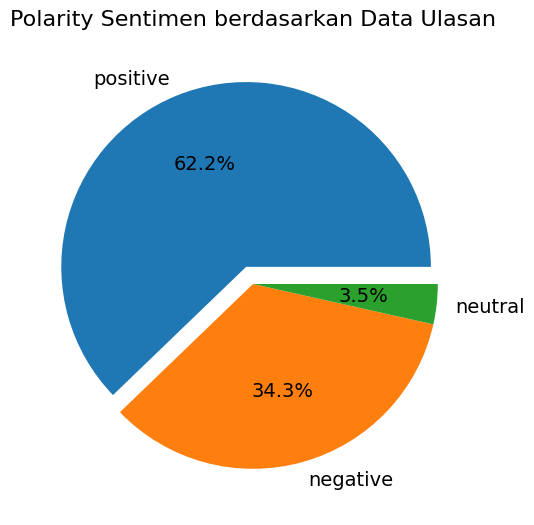

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
sizes = [count for count in df_clean['polarity'].value_counts()]
labels = list(df_clean['polarity'].value_counts().index)
explode = [0.1] + [0] * (len(sizes) - 1)
ax.pie(x=sizes, labels=labels, autopct='%1.1f%%', explode=explode, textprops={'fontsize': 14})
ax.set_title('Polarity Sentimen berdasarkan Data Ulasan', fontsize=16, pad=20)
plt.show()

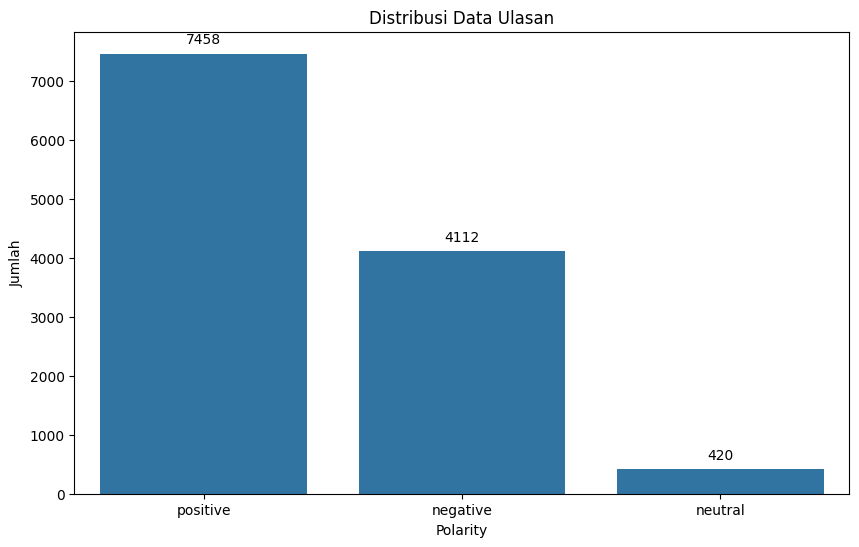

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

plt.figure(figsize=(10, 6))

class_dist_plot = sns.countplot(x='polarity', data=df_clean, order=['positive', 'negative', 'neutral'])
plt.title('Distribusi Data Ulasan')
plt.xlabel('Polarity')
plt.ylabel('Jumlah')

for p in class_dist_plot.patches:
    class_dist_plot.annotate(format(p.get_height(), '.0f'),
                              (p.get_x() + p.get_width() / 2., p.get_height()),
                              ha='center', va='center',
                              xytext=(0, 10),
                              textcoords='offset points')

plt.show()

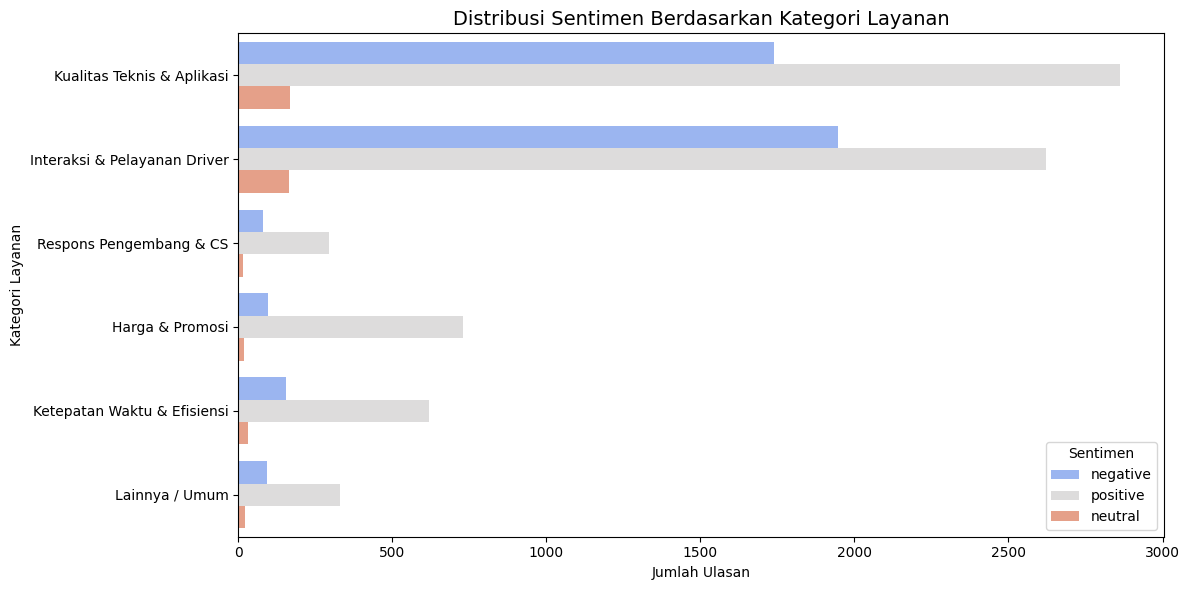

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat grafik batang sentimen berdasarkan kategori kuesioner
plt.figure(figsize=(12, 6))
sns.countplot(data=df_clean, y='Kategori', hue='polarity', palette='coolwarm')

plt.title('Distribusi Sentimen Berdasarkan Kategori Layanan', fontsize=14)
plt.xlabel('Jumlah Ulasan')
plt.ylabel('Kategori Layanan')
plt.legend(title='Sentimen')
plt.tight_layout()
plt.show()

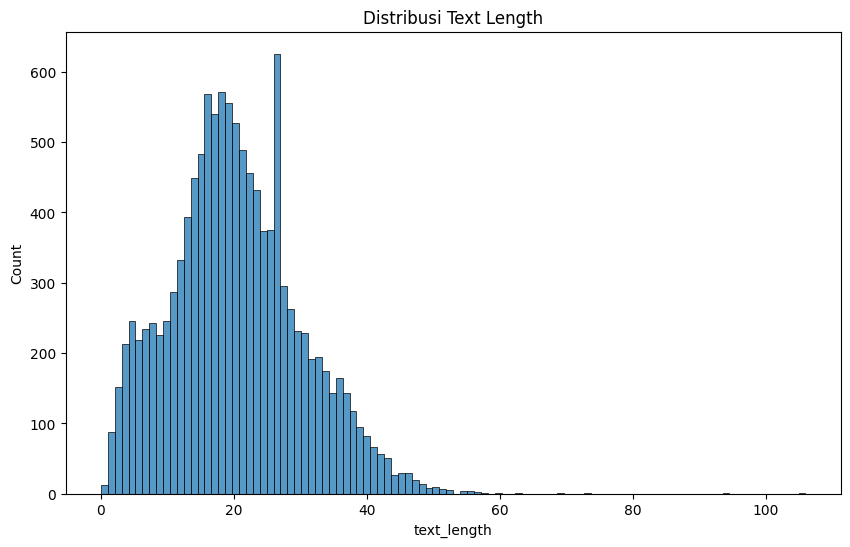

In [ ]:
plt.figure(figsize=(10, 6))

df_clean['text_length'] = df_clean['text_final'].apply(lambda x: len(x.split()))
sns.histplot(df_clean['text_length'])
plt.title('Distribusi Text Length')
plt.show()

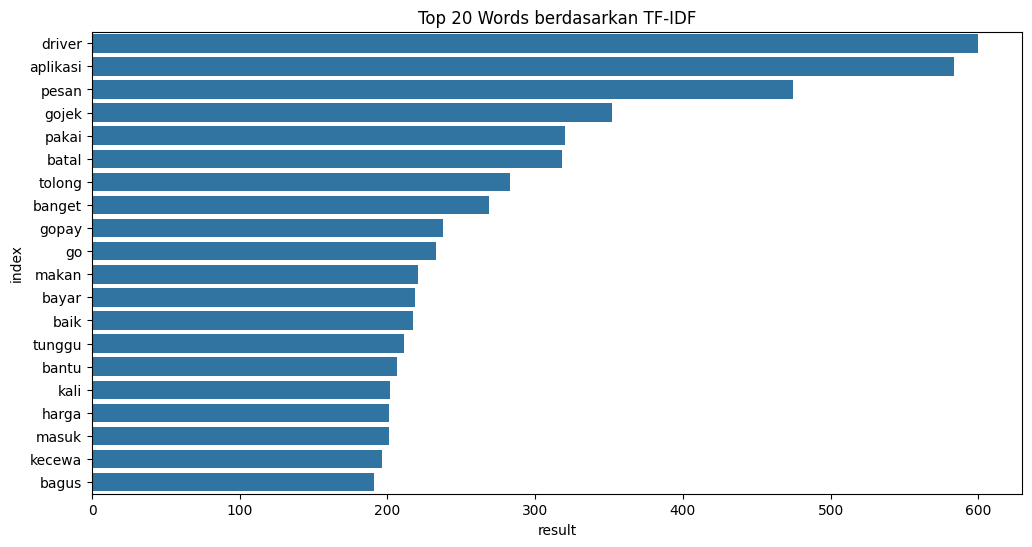

In [ ]:
plt.figure(figsize=(12, 6))
vectorizer = TfidfVectorizer()
x = vectorizer.fit_transform(df_clean['text_final'])
df_tfidf = pd.DataFrame(x.toarray(), columns=vectorizer.get_feature_names_out())
df_tfidf = df_tfidf.sum().reset_index(name='result')
df_tfidf = df_tfidf.sort_values('result', ascending=False).head(20)
sns.barplot(x='result', y='index', data=df_tfidf)
plt.title('Top 20 Words berdasarkan TF-IDF')
plt.show()

## 7. Word Cloud

**Word Cloud Positif**

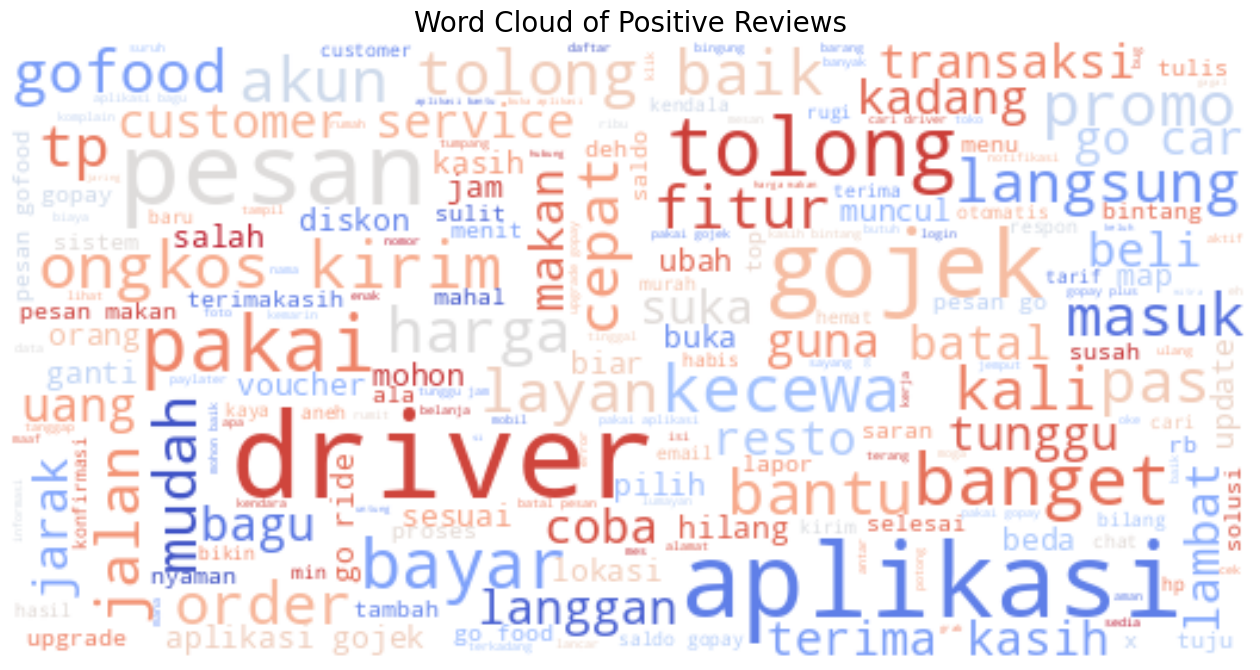

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Filter for positive sentiment reviews
positive_reviews = df_clean[df_clean['polarity'] == 'positive']

# Join the 'text_final' from positive reviews into a single string
Positive_msg_text = ' '.join(positive_reviews['text_final'])

Positive_msg_cloud = WordCloud(width =520,
                                height =260,
                                stopwords = STOPWORDS,
                                max_font_size = 50,
                                background_color = "white",
                                colormap = 'coolwarm').generate(Positive_msg_text)

plt.figure(figsize=(16,10))
plt.imshow(Positive_msg_cloud, interpolation = 'bilinear')
plt.axis('off')
plt.title('Word Cloud of Positive Reviews', fontsize=20)
plt.show()

**Word Cloud Negatif**

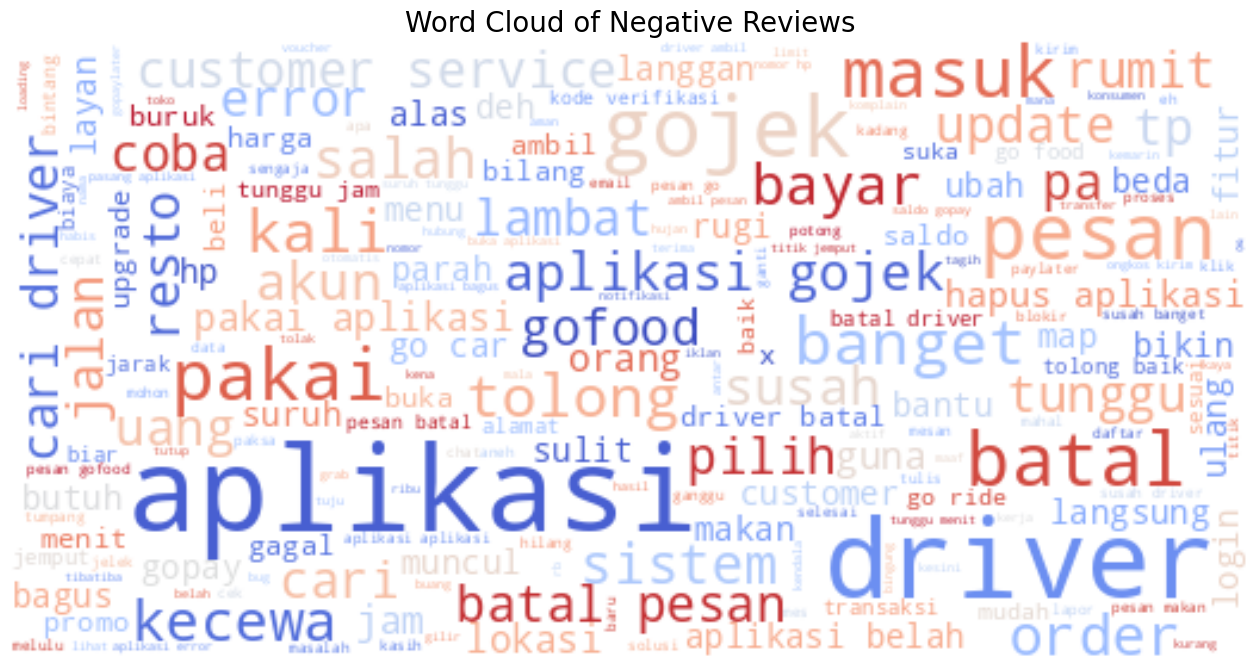

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Filter for negative sentiment reviews
negative_reviews = df_clean[df_clean['polarity'] == 'negative']

# Join the 'text_final' from negative reviews into a single string
Negative_msg_text = ' '.join(negative_reviews['text_final'])

Negative_msg_cloud = WordCloud(width =520,
                                height =260,
                                stopwords = STOPWORDS,
                                max_font_size = 50,
                                background_color = "white",
                                colormap = 'coolwarm').generate(Negative_msg_text)

plt.figure(figsize=(16,10))
plt.imshow(Negative_msg_cloud, interpolation = 'bilinear')
plt.axis('off')
plt.title('Word Cloud of Negative Reviews', fontsize=20)
plt.show()

**Word Cloud Netral**

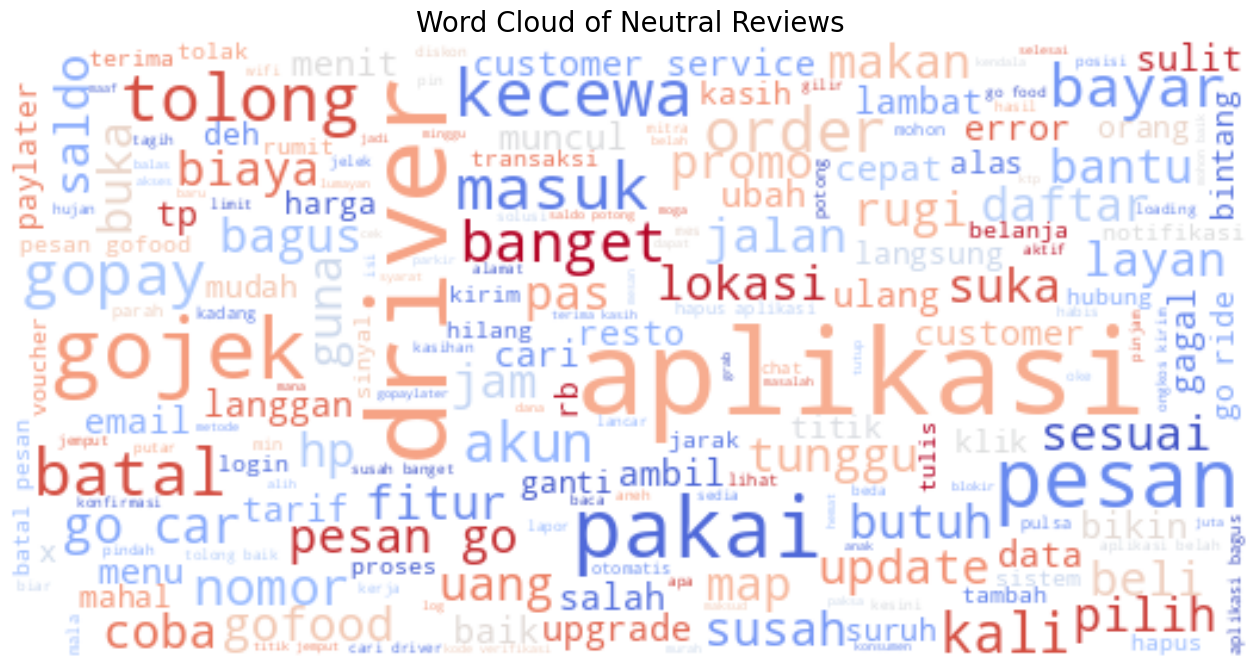

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Filter for neutral sentiment reviews
neutral_reviews = df_clean[df_clean['polarity'] == 'neutral']

# Join the 'text_final' from neutral reviews into a single string
Neutral_msg_text = ' '.join(neutral_reviews['text_final'])

Neutral_msg_cloud = WordCloud(width =520,
                                height =260,
                                stopwords = STOPWORDS,
                                max_font_size = 50,
                                background_color = "white",
                                colormap = 'coolwarm').generate(Neutral_msg_text)

plt.figure(figsize=(16,10))
plt.imshow(Neutral_msg_cloud, interpolation = 'bilinear')
plt.axis('off')
plt.title('Word Cloud of Neutral Reviews', fontsize=20)
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score

In [ ]:
X = df_clean['text_final']
y = df_clean['polarity']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df=10, max_df=0.8)
X_tfidf = tfidf.fit_transform(X)

In [ ]:
df_tfidf_features = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())
df_tfidf_features

,abai,abang,accord,account,ada,adain,adakan,adil,admin,adminnya,...,whatsapp,wifi,wilayah,wktu,worth,xjam,xl,yaaa,yng,youtube
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.586482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11985,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print(len(tfidf.get_feature_names_out()))

1628


In [ ]:
import numpy as np
from sklearn.feature_selection import SelectKBest, chi2

x_train_tfidf = np.array(df_tfidf_features)
y_train_tfidf = np.array(y)

selector_tfidf = SelectKBest(chi2, k=1000)
text_tfidf_selected = selector_tfidf.fit_transform(x_train_tfidf, y_train_tfidf)

print('Feature Number Asli', x_train_tfidf.shape[1])
print('Feature Number Pengurangan', text_tfidf_selected.shape[1])

Feature Number Asli 1628
Feature Number Pengurangan 1000


In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

oversampler_tfidf = SMOTE(random_state=2)
X_resampled_tfidf, y_resampled_tfidf = oversampler_tfidf.fit_resample(text_tfidf_selected, y_train_tfidf)

In [ ]:
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_resampled_tfidf, y_resampled_tfidf, test_size=0.1, random_state=42)

print('Jumlah X_train dataset : ', X_train_tfidf.shape)
print('Jumlah y_train dataset : ', y_train_tfidf.shape)

print('Jumlah X_test dataset : ', X_test_tfidf.shape)
print('Jumlah y_test dataset : ', y_test_tfidf.shape)

Jumlah X_train dataset :  (20136, 1000)
Jumlah y_train dataset :  (20136,)
Jumlah X_test dataset :  (2238, 1000)
Jumlah y_test dataset :  (2238,)


In [ ]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization

ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(1000,)),
    Dropout(0.5),
    BatchNormalization(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    BatchNormalization(),
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
ann_model.compile(optimizer='Adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
import tensorflow as tf
from keras.callbacks import EarlyStopping

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy') > 0.93 and logs.get('val_accuracy') > 0.93:
            print("\nAkurasi pelatihan dan validasi telah mencapai >93%! Pelatihan dihentikan.")
            self.model.stop_training = True
callbacks = myCallback()
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

Y_train_tfidf_encoded = label_encoder.fit_transform(y_train_tfidf)
Y_train_tfidf_one_hot = to_categorical(Y_train_tfidf_encoded)

Y_test_tfidf_encoded = label_encoder.transform(y_test_tfidf)
Y_test_tfidf_one_hot = to_categorical(Y_test_tfidf_encoded)

print("Mapping nilai encode:")
for label, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label}: {encoded_value}")

Mapping nilai encode:
negative: 0
neutral: 1
positive: 2


In [ ]:
history = ann_model.fit(X_train_tfidf,
                 Y_train_tfidf_one_hot,
                 validation_data=(X_test_tfidf, Y_test_tfidf_one_hot),
                 epochs=100,
                 batch_size=32,
                 callbacks = [callbacks,early_stop])

Epoch 1/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.6869 - loss: 0.7622 - val_accuracy: 0.8753 - val_loss: 0.3702
Epoch 2/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - accuracy: 0.8618 - loss: 0.3739 - val_accuracy: 0.9240 - val_loss: 0.2060
Epoch 3/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9115 - loss: 0.2498 - val_accuracy: 0.9339 - val_loss: 0.1713
Epoch 4/100
630/630 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9282 - loss: 0.1961 - val_accuracy: 0.9486 - val_loss: 0.1471
Epoch 5/100
626/630 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9385 - loss: 0.1649
Akurasi pelatihan dan validasi telah mencapai >93%! Pelatihan dihentikan.
630/630 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9417 - loss: 0.1638 - val_accuracy: 0.9482 - val_loss: 0.1408


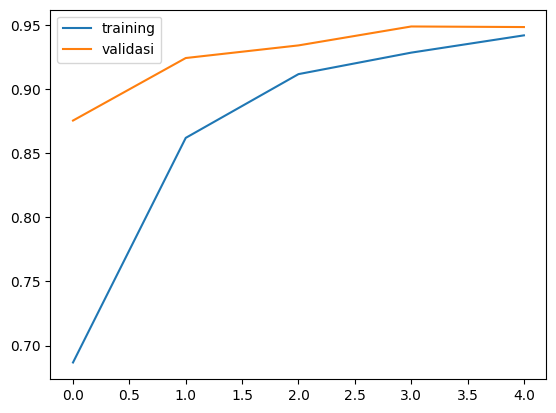

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='training')
plt.plot(history.history['val_accuracy'], label='validasi')
plt.legend()
plt.show()

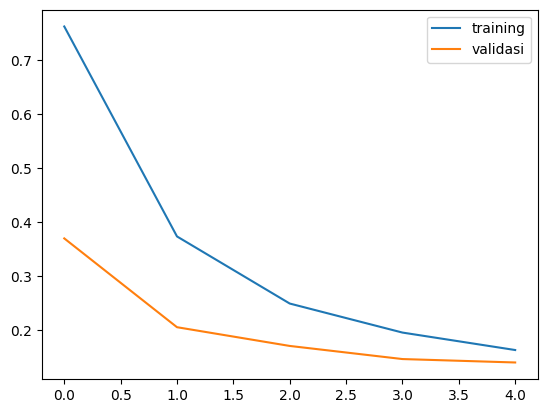

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='training')
plt.plot(history.history['val_loss'], label='validasi')
plt.legend()
plt.show()

## 8. Random Forest Model TF-IDF Cross Validation

### Ekstraksi Fitur TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df=10, max_df=0.8 )
X_tfidf = tfidf.fit_transform(X)

In [ ]:
df_tfidf_features = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

df_tfidf_features

,abai,abang,accord,account,ada,adain,adakan,adil,admin,adminnya,...,whatsapp,wifi,wilayah,wktu,worth,xjam,xl,yaaa,yng,youtube
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.586482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11985,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11986,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11987,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11988,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print(len(tfidf.get_feature_names_out()))

1628


## 9. Feature Selection

In [ ]:
import numpy as np

x_train_tfidf = np.array(df_tfidf_features)
y_train_tfidf = np.array(y)

from sklearn.feature_selection import SelectKBest, chi2

select_tfidf = SelectKBest(chi2, k=1000)
text_tfidf_selected = select_tfidf.fit_transform(x_train_tfidf, y_train_tfidf)

print('Feature Number Asli', x_train_tfidf.shape[1])
print('Feature Number Pengurangan', text_tfidf_selected.shape[1])

Feature Number Asli 1628
Feature Number Pengurangan 1000


## 10. SMOTE Oversampling

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

oversampler_tfidf = SMOTE(random_state=2)
X_resampled_tfidf, y_resampled_tfidf = oversampler_tfidf.fit_resample(text_tfidf_selected, y_train_tfidf)

## 11. Melatih Model Random Forest dengan Pembagian Cross Validation

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(bootstrap=False, max_depth=None, min_samples_leaf=1, min_samples_split=10, n_estimators=200)

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

SKF = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

accuracy_scores_train = []
accuracy_scores_test = []
confusion_matrixes = []

for train_index, test_index in SKF.split(X_resampled_tfidf, y_resampled_tfidf):
    X_train_fold, X_test_fold = X_resampled_tfidf[train_index], X_resampled_tfidf[test_index]
    y_train_fold, y_test_fold = y_resampled_tfidf[train_index], y_resampled_tfidf[test_index]

    random_forest.fit(X_train_fold, y_train_fold)
    y_predict_train = random_forest.predict(X_train_fold)
    acc_train_score = accuracy_score(y_train_fold, y_predict_train)
    accuracy_scores_train.append(acc_train_score)

    y_predict_test = random_forest.predict(X_test_fold)

    confusionn_matrix = confusion_matrix(y_test_fold, y_predict_test)
    confusion_matrixes.append(confusionn_matrix)

    acc_test_score = accuracy_score(y_test_fold, y_predict_test)
    accuracy_scores_test.append(acc_test_score)

for i, (confusionn_matrix, acc_train, acc_test) in enumerate(zip(confusion_matrixes, accuracy_scores_train, accuracy_scores_test), 1):
    print(f'Fold {i}:')
    print(f'Accuracy Train: {acc_train}')
    print(f'Accuracy Test: {acc_test}')
    print(f'Confusion Matrix:\n{confusionn_matrix}')

mean_acc_train_score = np.mean(accuracy_scores_train)
mean_acc_test_score = np.mean(accuracy_scores_test)

print(f'Mean Accuracy Train: {mean_acc_train_score}')
print(f'Mean Accuracy Test: {mean_acc_test_score}')

Fold 1:
Accuracy Train: 0.9995530393325387
Accuracy Test: 0.9222520107238605
Confusion Matrix:
[[650   6  90]
 [  3 741   2]
 [ 66   7 673]]
Fold 2:
Accuracy Train: 0.9996523639253079
Accuracy Test: 0.9177837354781054
Confusion Matrix:
[[668   1  77]
 [  1 743   2]
 [ 89  14 643]]
Fold 3:
Accuracy Train: 0.9997020262216925
Accuracy Test: 0.9133154602323503
Confusion Matrix:
[[648   3  95]
 [  1 744   1]
 [ 80  14 652]]
Fold 4:
Accuracy Train: 0.9995033770361541
Accuracy Test: 0.9110813226094727
Confusion Matrix:
[[639   6 101]
 [  2 741   3]
 [ 76  11 659]]
Fold 5:
Accuracy Train: 0.9995530615285295
Accuracy Test: 0.9137237371479661
Confusion Matrix:
[[653   3  90]
 [  0 744   1]
 [ 86  13 647]]
Fold 6:
Accuracy Train: 0.9995034016983662
Accuracy Test: 0.9141707644166294
Confusion Matrix:
[[658   4  84]
 [  1 740   4]
 [ 90   9 647]]
Fold 7:
Accuracy Train: 0.9997517008491831
Accuracy Test: 0.9043361645060348
Confusion Matrix:
[[628   8 110]
 [  1 743   2]
 [ 80  13 652]]
Fold 8:
Accur

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, balanced_accuracy_score, classification_report, precision_recall_fscore_support
import numpy as np

SKF = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

confusion_matrixes = []
accuracy_scores = []
balanced_accuracy_scores = []

# Initialize lists to store per-class metrics for each fold
precision_neg, recall_neg, f1_neg = [], [], []
precision_neu, recall_neu, f1_neu = [], [], []
precision_pos, recall_pos, f1_pos = [], [], []

# Assuming label_encoder.classes_ is available from previous cells, it should be ['Negative', 'Neutral', 'Positive']

for train_index, test_index in SKF.split(X_resampled_tfidf, y_resampled_tfidf):
  X_train_fold, X_test_fold = X_resampled_tfidf[train_index], X_resampled_tfidf[test_index]
  y_train_fold, y_test_fold = y_resampled_tfidf[train_index], y_resampled_tfidf[test_index]

  random_forest.fit(X_train_fold, y_train_fold)

  y_predict_fold = random_forest.predict(X_test_fold)

  confusionn_matrix = confusion_matrix(y_test_fold, y_predict_fold)
  confusion_matrixes.append(confusionn_matrix)

  acc_score = accuracy_score(y_test_fold, y_predict_fold)
  ball_acc_score = balanced_accuracy_score(y_test_fold, y_predict_fold)
  accuracy_scores.append(acc_score)
  balanced_accuracy_scores.append(ball_acc_score)

  # Calculate per-class metrics for the current fold
  # Using label_encoder.classes_ to ensure consistent ordering and handle cases where a class might be missing in a fold
  p, r, f1, _ = precision_recall_fscore_support(y_test_fold, y_predict_fold, labels=label_encoder.classes_, average=None, zero_division=0)

  precision_neg.append(p[0])
  recall_neg.append(r[0])
  f1_neg.append(f1[0])

  precision_neu.append(p[1])
  recall_neu.append(r[1])
  f1_neu.append(f1[1])

  precision_pos.append(p[2])
  recall_pos.append(r[2])
  f1_pos.append(f1[2])


for i, (confusionn_matrix, acc_score, ball_acc_score) in enumerate(zip(confusion_matrixes, accuracy_scores, balanced_accuracy_scores), 1):
  print(f'Fold {i}:')
  print(f'Accuracy: {acc_score:.4f}')
  print(f'Balanced Accuracy: {ball_acc_score:.4f}')
  print(f'Confusion Matrix:\n{confusionn_matrix}')

mean_acc_score = np.mean(accuracy_scores)
mean_bal_acc_score = np.mean(balanced_accuracy_scores)

mean_precision_neg = np.mean(precision_neg)
mean_recall_neg = np.mean(recall_neg)
mean_f1_neg = np.mean(f1_neg)

mean_precision_neu = np.mean(precision_neu)
mean_recall_neu = np.mean(recall_neu)
mean_f1_neu = np.mean(f1_neu)

mean_precision_pos = np.mean(precision_pos)
mean_recall_pos = np.mean(recall_pos)
mean_f1_pos = np.mean(f1_pos)


print(f'\nMean Accuracy CV: {mean_acc_score:.4f}')
print(f'Mean Balanced Accuracy CV: {mean_bal_acc_score:.4f}')
print('\nMean Metrics per Class (across folds):')
print(f'Negative (0): Precision={mean_precision_neg:.2f}, Recall={mean_recall_neg:.2f}, F1-score={mean_f1_neg:.2f}')
print(f'Neutral (1): Precision={mean_precision_neu:.2f}, Recall={mean_recall_neu:.2f}, F1-score={mean_f1_neu:.2f}')
print(f'Positive (2): Precision={mean_precision_pos:.2f}, Recall={mean_recall_pos:.2f}, F1-score={mean_f1_pos:.2f}')

Fold 1:
Accuracy: 0.9191
Balanced Accuracy: 0.9191
Confusion Matrix:
[[650   9  87]
 [  3 742   1]
 [ 74   7 665]]
Fold 2:
Accuracy: 0.9160
Balanced Accuracy: 0.9160
Confusion Matrix:
[[661   1  84]
 [  1 743   2]
 [ 88  12 646]]
Fold 3:
Accuracy: 0.9151
Balanced Accuracy: 0.9151
Confusion Matrix:
[[651   3  92]
 [  1 745   0]
 [ 82  12 652]]
Fold 4:
Accuracy: 0.9129
Balanced Accuracy: 0.9129
Confusion Matrix:
[[643   6  97]
 [  1 742   3]
 [ 78  10 658]]
Fold 5:
Accuracy: 0.9106
Balanced Accuracy: 0.9106
Confusion Matrix:
[[653   3  90]
 [  0 742   3]
 [ 89  15 642]]
Fold 6:
Accuracy: 0.9186
Balanced Accuracy: 0.9187
Confusion Matrix:
[[659   4  83]
 [  0 743   2]
 [ 83  10 653]]
Fold 7:
Accuracy: 0.9061
Balanced Accuracy: 0.9061
Confusion Matrix:
[[636   6 104]
 [  3 740   3]
 [ 80  14 651]]
Fold 8:
Accuracy: 0.9115
Balanced Accuracy: 0.9115
Confusion Matrix:
[[638   6 102]
 [  0 737   9]
 [ 73   8 664]]
Fold 9:
Accuracy: 0.9106
Balanced Accuracy: 0.9106
Confusion Matrix:
[[645   5  

### Analisis Laporan Klasifikasi Random Forest

Berdasarkan hasil rata-rata 10-fold _cross-validation_ untuk model Random Forest, dapat disimpulkan bahwa model menunjukkan kinerja yang solid dalam mengklasifikasikan sentimen ulasan. Akurasi rata-rata (Mean Accuracy CV) model adalah sekitar **91.35%**, dengan Akurasi Seimbang rata-rata (Mean Balanced Accuracy CV) yang serupa.

Secara spesifik, analisis metrik per kelas mengungkapkan:

*   **Sentimen Netral (1)**: Model menunjukkan kinerja yang sangat baik dalam mengidentifikasi sentimen netral, dengan Presisi rata-rata **0.98**, _Recall_ rata-rata **0.99**, dan F1-score rata-rata **0.99**. Hal ini mengindikasikan bahwa model jarang salah mengklasifikasikan sentimen lain sebagai netral (_high precision_) dan mampu menangkap hampir semua ulasan netral (_high recall_).

*   **Sentimen Negatif (0)**: Untuk sentimen negatif, model mencapai Presisi rata-rata **0.89**, _Recall_ rata-rata **0.87**, dan F1-score rata-rata **0.88**. Angka-angka ini menunjukkan kemampuan yang kuat dalam mengidentifikasi ulasan negatif, meskipun terdapat sedikit ruang untuk peningkatan dalam meminimalkan _false positives_ (Presisi) atau _false negatives_ (_Recall_).

*   **Sentimen Positif (2)**: Kinerja model untuk sentimen positif sedikit di bawah sentimen negatif, dengan Presisi rata-rata **0.87**, _Recall_ rata-rata **0.88**, dan F1-score rata-rata **0.87**. Meskipun masih tergolong baik, terdapat potensi untuk mengoptimalkan model agar lebih akurat dalam mengidentifikasi ulasan positif tanpa mengorbankan kelas lain secara signifikan.

Secara keseluruhan, model Random Forest menunjukkan kemampuan klasifikasi yang efektif, terutama dalam mengidentifikasi sentimen netral. Kinerja yang konsisten pada semua kelas sentimen menunjukkan robustnya model ini. Hasil ini memberikan dasar yang kuat untuk inferensi sentimen dalam dataset ulasan yang digunakan.

### Confusion Matrix dan Classification Report untuk Random Forest

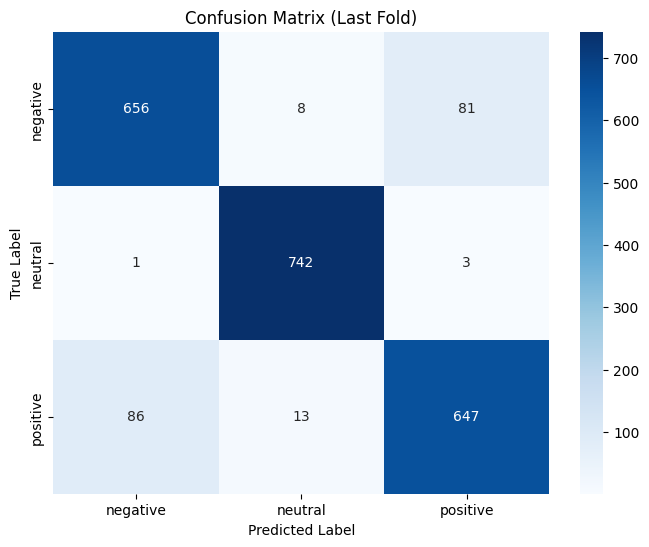

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using the last confusion matrix computed in the cross-validation loop
final_confusion_matrix = confusion_matrixes[-1]

plt.figure(figsize=(8, 6))
sns.heatmap(final_confusion_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix (Last Fold)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Classification Report Lengkap Random Forest

Berikut adalah detail metrik evaluasi untuk model Random Forest pada data pengujian.

In [ ]:
from sklearn.metrics import classification_report

# Mendapatkan prediksi dari model Random Forest pada fold terakhir untuk representasi laporan
y_pred_rf = random_forest.predict(X_test_fold)

# Mencetak Classification Report
print("Classification Report for Random Forest Model:\n")
print(classification_report(y_test_fold, y_pred_rf, target_names=label_encoder.classes_))

Classification Report for Random Forest Model:

              precision    recall  f1-score   support

    negative       0.88      0.88      0.88       745
     neutral       0.97      0.99      0.98       746
    positive       0.89      0.87      0.88       746

    accuracy                           0.91      2237
   macro avg       0.91      0.91      0.91      2237
weighted avg       0.91      0.91      0.91      2237



### Ringkasan Akurasi Random Forest (Setelah SMOTE)

Setelah menerapkan SMOTE untuk menyeimbangkan kelas, model Random Forest dilatih menggunakan *Stratified 10-Fold Cross Validation*. Berikut adalah ringkasan performanya:

In [ ]:
import numpy as np

# Menampilkan rata-rata akurasi dari hasil Cross-Validation yang sudah dijalankan
print(f'Rata-rata Akurasi Pelatihan (Training Accuracy): {mean_train_acc_score*100:.2f}%')
print(f'Rata-rata Akurasi Pengujian (Test Accuracy): {mean_test_acc_score*100:.2f}%')

# Menampilkan detail per fold untuk melihat konsistensi
print('\nDetail Akurasi per Fold (Test Set):')
for i, acc in enumerate(accuracy_scores_test, 1):
    print(f'Fold {i}: {acc*100:.2f}%')

Rata-rata Akurasi Pelatihan (Training Accuracy): 99.96%
Rata-rata Akurasi Pengujian (Test Accuracy): 91.40%

Detail Akurasi per Fold (Test Set):
Fold 1: 92.23%
Fold 2: 91.78%
Fold 3: 91.33%
Fold 4: 91.11%
Fold 5: 91.37%
Fold 6: 91.42%
Fold 7: 90.43%
Fold 8: 91.10%
Fold 9: 91.46%
Fold 10: 91.77%


## 12. RNN Model GRU dengan Tokenizer Keras

**Oversampling Class Imbalance**

In [ ]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(random_state=42)
X_resampled_gru, y_resampled_gru = oversampler.fit_resample(X.values.reshape(-1, 1), y)

In [ ]:
df_resampled  = pd.DataFrame(X_resampled_gru, columns=['text'])
df_resampled['polarity'] = y_resampled_gru

**Data Splitting**

In [ ]:
df_resampled['word_lenght'] = df_resampled['text'].str.split()
df_resampled['word_lenght'] = df_resampled['word_lenght'].str.len()
df_resampled.dropna(inplace=True)

In [ ]:
df_resampled.head(10)

,text,polarity,word_lenght
0,kakknapa coin bertambahtidk refras saldonyaset...,negative,15
1,driver suka abar jemput driver hindar batal ra...,negative,24
2,tolong jelas beda gofood gofood katering tampi...,positive,17
3,gojek gopay aneh dihp buka aplikasi wifi jarin...,positive,17
4,mohon maaf rating kendala transaksi qris coba ...,positive,28
5,jelek banget aplikasi bisa isi tuju jemput eh ...,positive,18
6,kemarin seliwer postingan tarik salah grup fb ...,positive,41
7,gojek ken ubah metode bayar apaa internet bagu...,positive,14
8,aplikasi tololpenipupemeras customerkita tawar...,positive,42
9,bagus aksesibel sandang disabilitas tunanetra ...,positive,18


In [ ]:
df_resampled['word_lenght'].sort_values(ascending=False)

,word_lenght
10803,106
10462,94
10433,73
10367,69
8031,63
...,...
21293,0
3586,0
21273,0
21464,0


In [ ]:
from sklearn.model_selection import train_test_split

X_train_gru, X_test_gru, y_train_gru, y_test_gru = train_test_split(df_resampled['text'], df_resampled['polarity'], test_size=0.1, random_state=42)

## 13. Preprocessing Text dengan Tokenizer Keras

In [ ]:
!pip install tensorflow
!pip install keras
from tensorflow.keras.preprocessing.text import Tokenizer

max_len = 200
trunc_type = 'post'
padding_type = 'post'
oov_tok = ''
vocab_size = 2000

tokenizer = Tokenizer(num_words = vocab_size, char_level=False, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train_gru)

In [ ]:
word_index = tokenizer.word_index
total_words = len(word_index)
total_words

16672

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

sequences_train_gru = tokenizer.texts_to_sequences(X_train_gru)
padded_train_gru = pad_sequences(sequences_train_gru, maxlen=max_len, padding=padding_type, truncating=trunc_type)

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

sequences_validation = tokenizer.texts_to_sequences(X_test_gru)
padded_validation = pad_sequences(sequences_validation, maxlen=max_len, padding=padding_type, truncating=trunc_type)

In [ ]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

label_encoder = LabelEncoder()

y_train_gru_encoded = label_encoder.fit_transform(y_train_gru)
y_train_gru_one_hot = to_categorical(y_train_gru_encoded)

y_test_gru_encoded = label_encoder.transform(y_test_gru)
y_test_gru_one_hot = to_categorical(y_test_gru_encoded)

print("Mapping Nilai Encode:")
for label, encoded_value in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
  print(f"{label}: {encoded_value}")

Mapping Nilai Encode:
negative: 0
neutral: 1
positive: 2


In [ ]:
print('Train tensor:', padded_train_gru.shape)
print('Test tensor:', padded_validation.shape)

Train tensor: (20136, 200)
Test tensor: (2238, 200)


## 14. GRU

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Embedding, Dropout, GlobalAveragePooling1D, Flatten, SpatialDropout1D, Bidirectional

embedding_dim = 128
drop_value = 0.2

gru_model = Sequential()
gru_model.add(Embedding(vocab_size,
                    embedding_dim,
                    input_length=max_len))
gru_model.add(GRU(64, return_sequences=True))
gru_model.add(GlobalAveragePooling1D())
gru_model.add(Dense(24, activation='relu'))
gru_model.add(Dropout(drop_value))
gru_model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
gru_model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
import tensorflow as tf
from keras.callbacks import EarlyStopping

class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy') > 0.93 and logs.get('val_accuracy') > 0.93:
            print("\nAkurasi train dan test telah mencapai >93%! Train dihentikan.")
            self.model.stop_training = True
callbacks = myCallback()
early_stop = EarlyStopping(monitor='val_loss', patience=5)

In [ ]:
history1 = gru_model.fit(padded_train_gru,
                    y_train_gru_one_hot,
                    epochs = 50,
                    batch_size = 32,
                    validation_data = (padded_validation, y_test_gru_one_hot),
                    callbacks = [early_stop, callbacks],
                    verbose=2)

Epoch 1/50
630/630 - 130s - 207ms/step - accuracy: 0.5250 - loss: 0.9345 - val_accuracy: 0.7784 - val_loss: 0.5508
Epoch 2/50
630/630 - 115s - 182ms/step - accuracy: 0.8749 - loss: 0.3546 - val_accuracy: 0.9182 - val_loss: 0.2315
Epoch 3/50

Akurasi train dan test telah mencapai >93%! Train dihentikan.
630/630 - 94s - 150ms/step - accuracy: 0.9477 - loss: 0.1598 - val_accuracy: 0.9446 - val_loss: 0.1535


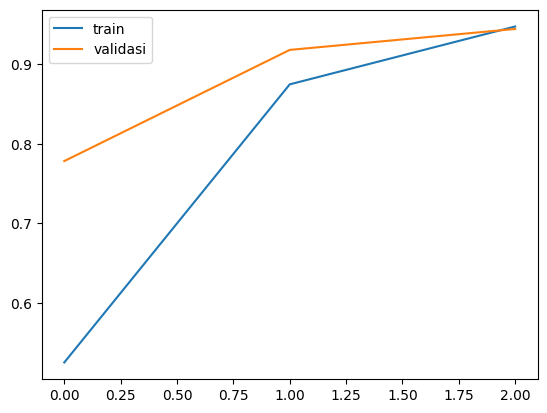

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history1.history['accuracy'], label='train')
plt.plot(history1.history['val_accuracy'], label='validasi')
plt.legend()
plt.show()

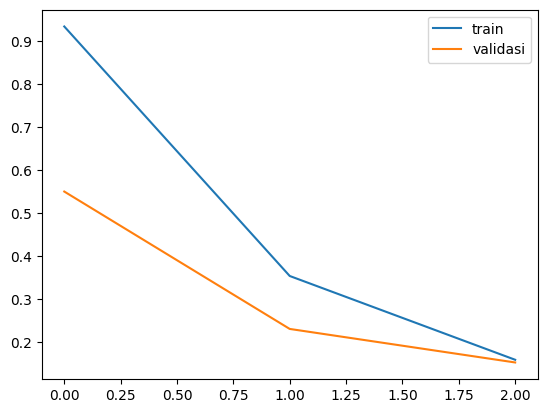

In [ ]:
plt.plot(history1.history['loss'], label='train')
plt.plot(history1.history['val_loss'], label='validasi')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Get predictions from the GRU model on the test set
y_pred_gru_one_hot = gru_model.predict(padded_validation)
y_pred_gru_encoded = np.argmax(y_pred_gru_one_hot, axis=1)

# Decode the actual test labels
y_test_gru_decoded = label_encoder.inverse_transform(y_test_gru_encoded)
y_pred_gru_decoded = label_encoder.inverse_transform(y_pred_gru_encoded)

# Generate and print the confusion matrix
cm_gru = confusion_matrix(y_test_gru_decoded, y_pred_gru_decoded, labels=label_encoder.classes_)
print('Confusion Matrix for GRU Model:\n', cm_gru)

# Generate and print the classification report
print('\nClassification Report for GRU Model:\n')
print(classification_report(y_test_gru_decoded, y_pred_gru_decoded, target_names=label_encoder.classes_))

70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
Confusion Matrix for GRU Model:
 [[708  13  43]
 [  0 716   0]
 [ 51  17 690]]

Classification Report for GRU Model:

              precision    recall  f1-score   support

    negative       0.93      0.93      0.93       764
     neutral       0.96      1.00      0.98       716
    positive       0.94      0.91      0.93       758

    accuracy                           0.94      2238
   macro avg       0.94      0.95      0.94      2238
weighted avg       0.94      0.94      0.94      2238



### Visualisasi Classification Report GRU

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import classification_report
import numpy as np

# Re-run prediction and classification report to get the exact data for GRU
# This is taken from the output of cell `JpcxGu9jQSNN`
y_pred_gru_one_hot = gru_model.predict(padded_validation)
y_pred_gru_encoded = np.argmax(y_pred_gru_one_hot, axis=1)
y_test_gru_decoded = label_encoder.inverse_transform(y_test_gru_encoded)
y_pred_gru_decoded = label_encoder.inverse_transform(y_pred_gru_encoded)

report = classification_report(y_test_gru_decoded, y_pred_gru_decoded, target_names=label_encoder.classes_, output_dict=True)

# Extract data for plotting
gru_data = {
    'Metric': [],
    'Class': [],
    'Score': []
}

for cls in label_encoder.classes_:
    gru_data['Metric'].extend(['Precision', 'Recall', 'F1-score'])
    gru_data['Class'].extend([cls] * 3)
    gru_data['Score'].extend([
        report[cls]['precision'],
        report[cls]['recall'],
        report[cls]['f1-score']
    ])

gru_df = pd.DataFrame(gru_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Class', y='Score', hue='Metric', data=gru_df, palette='viridis')
plt.ylim(0, 1) # Scores are between 0 and 1
plt.title('GRU Classification Report')
plt.ylabel('Score')
plt.xlabel('Class')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

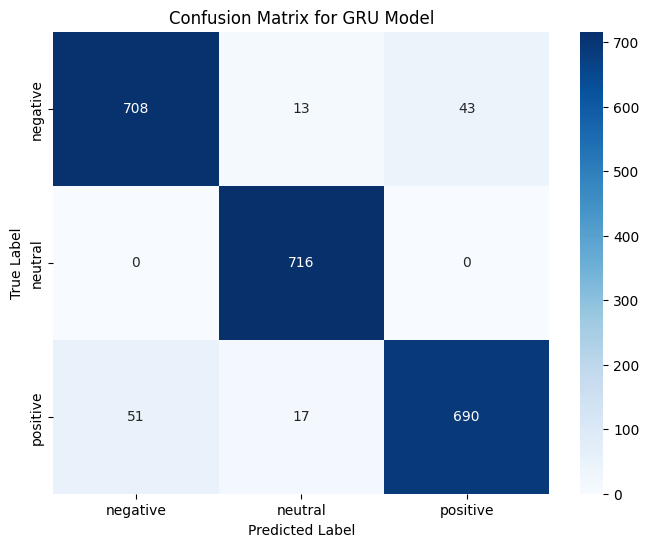

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(cm_gru, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for GRU Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 15. Perbandingan 3 Percobaan Test dari 3 Model, 2 Ekstraksi Fitur, 2 Data Split yang Berbeda

In [ ]:
import numpy as np

# Model GRU
gru_train = gru_model.evaluate(padded_train_gru, np.asarray(y_train_gru_one_hot), verbose=2, batch_size=32)
gru_test = gru_model.evaluate(padded_validation, np.asarray(y_test_gru_one_hot), verbose=2, batch_size=32)

# Model ANN
ann_train = ann_model.evaluate(X_train_tfidf, np.asarray(Y_train_tfidf_one_hot), verbose=2, batch_size=32)
ann_test = ann_model.evaluate(X_test_tfidf, np.asarray(Y_test_tfidf_one_hot), verbose=2, batch_size=32)

mean_train_acc_score = np.mean(accuracy_scores_train)
mean_test_acc_score = np.mean(accuracy_scores_test)

print()
print(f'Accuracy Train Mean Random Forest : {mean_train_acc_score*100:0.2f} Mean Test Accuracy RF : {mean_test_acc_score*100:0.2f}')
print(f'Accuracy Train GRU : {gru_train[1]*100:0.2f} Test Accuracy GRU : {gru_test[1]*100:0.2f}')
print(f'Accuracy Train ANN : {ann_train[1]*100:0.2f} Test Accuracy ANN : {ann_test[1]*100:0.2f}')

630/630 - 31s - 49ms/step - accuracy: 0.9773 - loss: 0.0743
70/70 - 2s - 28ms/step - accuracy: 0.9446 - loss: 0.1535
630/630 - 1s - 2ms/step - accuracy: 0.9890 - loss: 0.0530
70/70 - 0s - 2ms/step - accuracy: 0.9482 - loss: 0.1408

Accuracy Train Mean Random Forest : 99.96 Mean Test Accuracy RF : 91.40
Accuracy Train GRU : 97.73 Test Accuracy GRU : 94.46
Accuracy Train ANN : 98.90 Test Accuracy ANN : 94.82


## 16. Testing

In [ ]:
new_kalimat = input("Masukkan kalimat baru: ")

new_kalimat_cleaned = cleaningText(new_kalimat)
new_kalimat_casefolded = casefoldingText(new_kalimat_cleaned)
new_kalimat_slangfixed = fix_slangwords(new_kalimat_casefolded)
new_kalimat_tokenized = tokenizingText(new_kalimat_slangfixed)
new_kalimat_filtered = filteringText(new_kalimat_tokenized)
new_kalimat_akhir = toSentence(new_kalimat_filtered)

X_new_kalimat = tfidf.transform([new_kalimat_akhir])

X_new_kalimat = pd.DataFrame(X_new_kalimat.toarray(), columns=tfidf.get_feature_names_out())

new = np.array(X_new_kalimat)

selector = select_tfidf.transform(new)

new_prediksi = random_forest.predict(selector)

predicted_index = np.argmax(new_prediksi)

if predicted_index == 0:
    print("Sentimen kalimat baru adalah baru adalah POSITIVE.")
elif predicted_index == 1:
    print("Sentimen kalimat baru adalah NEUTRAL.")
else:
    print("Sentimen kalimat baru adalah NEGATIVE.")

Masukkan kalimat baru: Aplikasinya sangat membantu untuk transportasi
Sentimen kalimat baru adalah baru adalah POSITIVE.
